---
tags: [algorithm, finance, simulation]
---

# Option Pricing with Quantum Amplitude Estimation

Quantum amplitude estimation on gate-based quantum computers has been proposed for a wide range of applications.
Option pricing in financial engineering is one of its representative applications.
Classical Monte Carlo methods have traditionally been used for option pricing and require $\mathcal{O}(\epsilon^{-2})$ oracle calls to reach a target precision $\epsilon$.
In contrast, quantum amplitude estimation requires $\mathcal{O}(\epsilon^{-1})$ calls, providing a quadratic speedup.
This article explains and implements a quantum amplitude estimation approach to option and option-portfolio pricing {cite:p}`10.22331/q-2020-07-06-291`. Use this option-pricing example to learn how to work with Qamomile.

In [1]:
# Install the latest Qamomile through pip!
#!pip install qamomile

In [2]:
import numpy as np
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator

import qamomile.circuit as qmc
from qamomile.circuit.stdlib import amplitude_encoding
from qamomile.qiskit import QiskitTranspiler

## Background

First, let us define the terms used in this article.

* Asset: a financial instrument, such as a stock, that underlies an option.
* Option: a right to buy or sell an asset at a specified price on a future date (the maturity date).
* Payoff: the value of an option at maturity.

### The option-pricing problem

Financial risk calculations are in high demand.
Monte Carlo (MC) methods are central to these calculations and are widely used for estimating value at risk (VaR) and pricing over-the-counter derivatives.
Their drawback is that the error decays as $\varepsilon = \mathcal{O} (M^{-1/2})$.
Here, $M$ is the number of samples.
When the target probability distribution can be prepared as a quantum state, quantum amplitude estimation (QAE) can estimate statistics such as expected values with error $\mathcal{O} (M^{-1})$.
This provides a quadratic speedup over classical MC.

### Prior work

A theoretical framework for quantum algorithms for Monte Carlo pricing was presented in {cite:p}`10.1103/PhysRevA.98.022321`.
The paper theoretically showed a quadratic speedup over classical pricing calculations.
It also demonstrated numerical simulations for European and Asian options.
However, its contribution was limited to a theoretical framework and numerical simulations; it did not demonstrate execution on quantum hardware.
Another important work is {cite:p}`10.1038/s41534-019-0130-6`.
Rather than pricing, it applied QAE to value at risk (VaR) and conditional value at risk (CVaR).
It improved the payoff calculation of the Monte Carlo pricing framework, substantially reducing the required number of qubits and gates {cite:p}`10.1103/PhysRevA.98.022321`.
An implementation then extended that payoff-calculation method to option pricing {cite:p}`10.22331/q-2020-07-06-291`.

## Algorithm: Option pricing with QAE

### Calculating the payoff

QAE repeats the Grover operator $\mathcal{Q}$ $k$ times, causing the measurement probability to follow the known form
$\sin^2((2k+1)\theta_a)$.
This makes it possible to estimate $\theta_a$ accurately with relatively few measurements.
Let $S_i$ be an asset price and $p_i$ its probability.
Suppose that an operator $\mathcal{A}$ prepares the state

$$
\mathcal{A} \vert 0 \rangle_{n+1}
= \sum_{i=0}^{2^n - 1} \sqrt{1-f(S_i)} \sqrt{p_i} \vert S_i \rangle \vert 0 \rangle + \sum_{i=0}^{2^n - 1} \sqrt{f(S_i)} \sqrt{p_i} \vert S_i \rangle \vert 1 \rangle \tag{1}
$$

Then the probability of observing the payoff qubit in $\vert 1 \rangle$ is $a = \mathbb{E}[f(S)]$, allowing QAE to calculate the expected payoff.
A binary payoff representation in an auxiliary register increases the number of qubits and circuit depth {cite:p}`10.1103/PhysRevA.98.022321`.
The lightweight $R_y$ method avoids this overhead {cite:p}`10.22331/q-2020-07-06-291,10.1038/s41534-019-0130-6`.

### Applying the method to an expected value and the parameter $c$

To expand around $\pi/4$, where the derivative of $\sin^2$ is maximal, define the target amplitude angle as

$$
\tilde{f}(i) = 2 \frac{f(i) - f_\mathrm{min}}{f_\mathrm{max} - f_\mathrm{min}} - 1, \qquad
\alpha(i) = c\tilde{f}(i) + \frac{\pi}{4} \tag{2}
$$

where $c \in [0, 1]$ is a scaling parameter.
The probability that the payoff qubit is $\vert 1 \rangle$ is then

$$
P_1 \approx \frac{1}{2} + c\,\mathbb{E}[\tilde{f}] + \mathcal{O}(c^3) \tag{3}
$$

Estimating $P_1$ lets us calculate $\mathbb{E}[f(S)]$ from the known values of $c$, $f_\mathrm{min}$, and $f_\mathrm{max}$.
If the estimation error of $P_1$ is $\delta P_1$, then $\mathbb{E}[\tilde{f}] \approx (P_1 - 1/2)/c$, so the estimation error is amplified to $\delta P_1/c$.
Reducing $c$ increases this amplification, while increasing $c$ increases the approximation bias $\mathcal{O}(c^2)$.
This tradeoff gives a convergence rate of $\mathcal{O}(M^{-2/3})$.
Although this does not reach a full quadratic speedup, it still outperforms the classical MC rate of $\mathcal{O}(M^{-1/2})$.
The implementation below uses lightweight maximum-likelihood amplitude estimation (MLAE), which does not require phase estimation.

### Applying the method to a call option

The payoff of a call option, $f_C(S_T) = \max(0, S_T - K)$, is a piecewise-linear function with a kink at $K$.
This implementation uses uniformly controlled $R_y$ rotations (UCR-Y) to apply the target amplitude angle at each grid point $S_i$:

$$
\alpha(S_i) = \frac{\pi}{4} - c + \frac{2c\,\max(S_i - K,\,0)}{S_\mathrm{max} - K} \tag{4}
$$

This directly applies the target amplitude angle.
For $S < K$ the angle is the constant $\pi/4 - c$, and for $S \geq K$ it increases linearly, so this piecewise-linear structure can be encoded exactly.

## Implementation with Qamomile

### Preparing the distribution

Let us now examine the option-pricing implementation {cite:p}`10.22331/q-2020-07-06-291`.
First, we prepare a discretized log-normal distribution for the asset price at maturity $S_T$ under geometric Brownian motion.

In [3]:
n_qubits = 4
S0, K, r, sigma, T = 2.0, 1.9, 0.05, 0.4, 40 / 365
mu  = (r - 0.5 * sigma**2) * T
std = sigma * np.sqrt(T)
S_min = float(S0 * np.exp(mu - 3 * std))
S_max = float(S0 * np.exp(mu + 3 * std))
S_grid = np.linspace(S_min, S_max, 2**n_qubits)

def lognpdf(S):
    return (np.exp(-(np.log(S / S0) - mu)**2 / (2 * std**2))
            / (S * std * np.sqrt(2 * np.pi)))

probs = lognpdf(S_grid)
probs /= probs.sum()
amps  = np.sqrt(probs)   # Amplitudes sqrt(p_i) for Mottönen encoding

c     = 0.25             # Scaling parameter
F_max = float(S_max - K)

# ── Target amplitude angles ──
payoff       = np.maximum(S_grid - K, 0.0)
alpha_target = np.pi / 4 - c + 2 * c * payoff / F_max   # shape: (2^n,)

# ── Reference values ──
# exact_E_f: exact expected payoff from numerical integration over the discrete grid
exact_E_f  = float(np.sum(probs * payoff))
exact_fair = np.exp(-r * T) * exact_E_f

# Exact P1: sum_i p_i sin^2(alpha_i), without using the linear approximation
P1_exact  = float(np.sum(probs * np.sin(alpha_target)**2))

# Approximate P1
E_ftilde  = 2 * exact_E_f / F_max - 1
P1_approx = c * E_ftilde + 0.5

print(f"Expected payoff (numerical integration): {exact_E_f:.6f}")
print(f"Fair value (reference):                 {exact_fair:.6f}")
print(f"Exact P1:                               {P1_exact:.6f}")
print(f"Approximate P1 (linear approximation):  {P1_approx:.6f}")
print(f"P1 approximation error:                 {abs(P1_exact - P1_approx):.6f}")

Expected payoff (numerical integration): 0.167010
Fair value (reference):                 0.166098
Exact P1:                               0.333988
Approximate P1 (linear approximation):  0.328358
P1 approximation error:                 0.005631


### Implementing the payoff operator

As shown in the algorithm section, the call-option payoff $f(S) = \max(S-K, 0)$ is piecewise linear with a kink at $K$.
We therefore need to apply a different target amplitude angle at every grid point:

$$
\alpha(S_i) = \frac{\pi}{4} - c + \frac{2c\,\max(S_i - K,\, 0)}{S_\mathrm{max} - K}
$$

UCR-Y can apply an independent amplitude angle $\alpha(S_i)$ to each basis state $\vert i \rangle$, which lets us encode the piecewise-linear structure around $K$ exactly.
The following implementation decomposes UCR-Y into only $R_y$ gates and CNOT gates.

In [4]:
# ── Precompute the UCR-Y gate list with Python-level recursion ──
def _ucry_recursive(angles, ctrl_indices, tgt_index, gates):
    """Recursively demultiplex UCR-Y and append gates as ('ry'|'cx', ...) tuples."""
    if len(ctrl_indices) == 0:
        if abs(angles[0]) > 1e-12:
            gates.append(('ry', tgt_index, angles[0]))
        return
    m = len(angles) // 2
    a = [(angles[i] + angles[i + m]) / 2 for i in range(m)]
    b = [(angles[i] - angles[i + m]) / 2 for i in range(m)]
    _ucry_recursive(a, ctrl_indices[:-1], tgt_index, gates)
    gates.append(('cx', ctrl_indices[-1], tgt_index))
    _ucry_recursive(b, ctrl_indices[:-1], tgt_index, gates)
    gates.append(('cx', ctrl_indices[-1], tgt_index))

# UCR-Y rotation angles are twice the amplitude angles because
# Ry(theta)|0> = cos(theta/2)|0> + sin(theta/2)|1> in Qamomile.
ucry_gates = []
_ucry_recursive(
    (2 * alpha_target).tolist(),   # Pass twice the amplitude angles alpha
    list(range(n_qubits)),          # Controls: q_S[0..n-1]
    n_qubits,                       # Target: payoff qubit (index n_qubits)
    ucry_gates
)

# Adjoint UCR-Y gate list: reverse the order and negate Ry angles
ucry_inv_gates = []
for gate in reversed(ucry_gates):
    if gate[0] == 'ry':
        ucry_inv_gates.append(('ry', gate[1], -gate[2]))
    else:  # CNOT is self-inverse
        ucry_inv_gates.append(gate)

print(f"Number of UCR-Y gates: {len(ucry_gates)} (Ry + CNOT)")

# Return a function that applies the UCR-Y gate list inside a quantum kernel.
def _make_ucry_func(gate_list):
    """Return a function that applies the UCR-Y gate list in order."""
    def apply_ucry(q_S, q_p):
        for gate in gate_list:
            if gate[0] == 'ry':
                q_p = qmc.ry(q_p, gate[2])
            else:                                       # 'cx': CNOT
                q_S[gate[1]], q_p = qmc.cx(q_S[gate[1]], q_p)
        return q_S, q_p
    return apply_ucry

apply_payoff_ucr     = _make_ucry_func(ucry_gates)      # F  (payoff circuit)
apply_payoff_ucr_inv = _make_ucry_func(ucry_inv_gates)  # F dagger (payoff adjoint)

Number of UCR-Y gates: 46 (Ry + CNOT)


### Implementing distribution loading

Next, let us implement the operation that loads the prepared asset-price data and its Hermitian adjoint.
Qamomile provides the amplitude-encoding function, `amplitude_encoding`, as part of its standard library.

In [5]:
# ── P_X and P_X dagger (distribution loading and its adjoint) ──
@qmc.qkernel
def load_distribution(q: qmc.Vector[qmc.Qubit]) -> qmc.Vector[qmc.Qubit]:
    """Load the log-normal distribution with Mottönen encoding."""
    q = amplitude_encoding(q, amps.tolist())
    return q

# Automatically generate the adjoint with qmc.inverse.
load_distribution_inv = qmc.inverse(load_distribution)

Combining distribution loading with UCR-Y gives a circuit that encodes the call-option payoff into the amplitude of the payoff qubit.
Run `num_shots` measurements to estimate the probability $P_1$ that the payoff qubit is $\vert 1 \rangle$.
We then calculate the expected payoff from the approximation in equation (3), $P_1 \approx \frac{1}{2} + c\mathbb{E}[\tilde{f}]$.
Showing that the measured $P_1$ is close to the theoretical value verifies that the payoff circuit works correctly.

In [6]:
@qmc.qkernel
def payoff_call() -> qmc.Bit:
    q_S = qmc.qubit_array(n_qubits, "q_S")
    q_p = qmc.qubit(name="q_p")

    # (1) Load the distribution: P_X
    q_S = load_distribution(q_S)

    # (2) UCR-Y payoff circuit: F
    #     |i>|0> -> |i>(cos alpha(i)|0> + sin alpha(i)|1>)
    #     alpha(i) = pi/4 - c + 2c*max(S_i-K, 0) / (S_max-K)
    #     S < K: constant angle pi/4 - c; S >= K: linear increase
    q_S, q_p = apply_payoff_ucr(q_S, q_p)

    _ = qmc.measure(q_S)
    return qmc.measure(q_p)


num_shots      = 4096
transpiler_qmc = QiskitTranspiler()
simulator      = AerSimulator(seed_simulator=42)
executor_qmc   = transpiler_qmc.executor(simulator)
exe_k0 = transpiler_qmc.transpile(payoff_call)   # No bindings required
res_k0 = exe_k0.sample(executor_qmc, shots=num_shots).result()

ones_k0 = 0
for q, num in res_k0.results:
    if q == 1:
        ones_k0 += num
P1_k0 = ones_k0 / num_shots

print(f"\n[Qamomile k=0]")
print(f"Measured P1:             {P1_k0:.4f}")
print(f"Exact P1 (reference):    {P1_exact:.4f}")
print(f"Approximate P1:          {P1_approx:.4f}")
print("-> The payoff circuit works correctly when the measurement is close to the exact value.")


[Qamomile k=0]
Measured P1:             0.3313
Exact P1 (reference):    0.3340
Approximate P1:          0.3284
-> The payoff circuit works correctly when the measurement is close to the exact value.


### Implementing quantum amplitude estimation

Let us construct a circuit that applies the Grover operator $\mathcal{Q} = \mathcal{A} \mathcal{S}_0 \mathcal{A}^\dagger \mathcal{S}_\chi$ $k$ times for amplitude estimation.
For the state after $k$ applications, we calculate the probability that the payoff qubit is $\vert 1 \rangle$: $P_1^{(k)} = \sin^2 ((2k+1) \theta_\alpha)$.

In [7]:
def build_Ak_kernel(k: int):
    """Build A · Q^k with a single definition for every n_qubits value using mcx."""

    @qmc.qkernel
    def Ak() -> qmc.Bit:
        q_S = qmc.qubit_array(n_qubits, "q_S")
        q_p = qmc.qubit(name="q_p")

        # ── A = P_X · F ──
        q_S = load_distribution(q_S)
        q_S, q_p = apply_payoff_ucr(q_S, q_p)

        # ── Apply Q k times ──
        for _ in range(k):

            # S_chi: apply phase -1 when the payoff qubit is |1>
            q_p = qmc.z(q_p)

            # A dagger = F dagger · P_X dagger
            q_S, q_p = apply_payoff_ucr_inv(q_S, q_p)
            q_S = load_distribution_inv(q_S)

            # S_0: apply phase -1 to |0...0>
            # Invert with X, apply MCZ (= H · MCX · H), then restore with X.
            # Controls: all of q_S; target: q_p. No ancilla is required.
            q_S = qmc.x(q_S)
            q_p = qmc.x(q_p)
            q_p = qmc.h(q_p)
            q_S[0:n_qubits], q_p = qmc.mcx(q_S[0:n_qubits], q_p)
            q_p = qmc.h(q_p)
            q_S = qmc.x(q_S)
            q_p = qmc.x(q_p)

            # A
            q_S = load_distribution(q_S)
            q_S, q_p = apply_payoff_ucr(q_S, q_p)

        _ = qmc.measure(q_S)
        return qmc.measure(q_p)

    return Ak

k_list      = [0, 1, 2, 4, 8, 16]
shots_per_k = 2048

transpiler_q = QiskitTranspiler()
executor_q   = transpiler_q.executor(simulator)
h_list, N_list = [], []

# Use the exact value, rather than the linear approximation, for the P1 theory.
theta_a_theory = np.arcsin(np.sqrt(max(0.0, min(1.0, P1_exact))))
print()
for k in k_list:
    kernel = build_Ak_kernel(k)
    exe    = transpiler_q.transpile(kernel)   # No bindings required
    result = exe.sample(executor_q, shots=shots_per_k).result()

    ones = 0
    for q, num in result.results:
        if q == 1:
            ones += num
    h_list.append(ones)
    N_list.append(shots_per_k)
    P1_k  = ones / shots_per_k
    P1_th = np.sin((2*k + 1) * theta_a_theory)**2
    print(f"k={k:2d}: measured P1={P1_k:.4f}, theoretical (exact) P1={P1_th:.4f}")


k= 0: measured P1=0.3228, theoretical (exact) P1=0.3340


k= 1: measured P1=0.9160, theoretical (exact) P1=0.9248


k= 2: measured P1=0.0029, theoretical (exact) P1=0.0037


k= 4: measured P1=0.4565, theoretical (exact) P1=0.4523


k= 8: measured P1=0.7485, theoretical (exact) P1=0.7526


k=16: measured P1=0.9917, theoretical (exact) P1=0.9925


## Results

Based on the measurements at several $k$ values (binomial data), let us perform maximum-likelihood estimation with the model $P_1^{(k)} = \sin^2 ((2k+1) \theta_\alpha)$.
This estimates the amplitude angle $\theta_\alpha$, from which we calculate $P_1 = \sin^2 \theta_\alpha$.
We then calculate the expected payoff $\mathbb{E}[f(S)]$ from $P_1$ and discount it at the risk-free rate to obtain the option's fair value.
Finally, we compare it with a reference value from an exact calculation.

In [8]:
# ============================================================
# 4. Maximum-likelihood estimation (MLE)
# ============================================================
def neg_log_lik(theta: float) -> float:
    """
    Negative log likelihood:
      -sum_k [h_k log sin^2((2k+1)theta) + (N_k - h_k) log cos^2((2k+1)theta)]
    """
    ll = 0.0
    for k, h, N in zip(k_list, h_list, N_list):
        s2 = float(np.clip(np.sin((2*k + 1) * theta)**2, 1e-12, 1 - 1e-12))
        ll += h * np.log(s2) + (N - h) * np.log(1 - s2)
    return -ll

opt       = minimize_scalar(neg_log_lik, bounds=(0, np.pi / 2), method='bounded')
theta_hat = opt.x
a_hat     = np.sin(theta_hat)**2

# Recover E[f(S)] from P1 with the equation (3) linear approximation;
# its approximation bias is O(c^2).
# E[f_tilde] approx (P1 - 1/2) / c, E[f] = F_max/2 * (E[f_tilde] + 1)
E_ftilde_hat = (a_hat - 0.5) / c
E_f_hat      = (E_ftilde_hat + 1) * F_max / 2
fair_hat     = np.exp(-r * T) * E_f_hat

print(f"\n===== Estimation results =====")
print(f"Estimated P1:          {a_hat:.6f}  "
      f"(exact {P1_exact:.6f}, approximation {P1_approx:.6f})")
print(f"Estimated E[f(S)]:     {E_f_hat:.6f}  (reference {exact_E_f:.6f})")
print(f"Estimated fair value:  {fair_hat:.6f}  (reference {exact_fair:.6f})")
print(f"Absolute error:        {abs(fair_hat - exact_fair):.6f}")


===== Estimation results =====
Estimated P1:          0.333861  (exact 0.333988, approximation 0.328358)
Estimated E[f(S)]:     0.178741  (reference 0.167010)
Estimated fair value:  0.177764  (reference 0.166098)
Absolute error:        0.011666


The value `E[f(S)]` estimated from the quantum circuit differs from the reference value because it uses the approximation

$$
\mathbb{E}[f] = \frac{F_\mathrm{max}}{2} \left( \frac{P_1 - \frac{1}{2}}{c} + 1 \right)
$$

where $F_\mathrm{max} = S_\mathrm{max} - K$.
Let us quantify how much of the difference between the estimated $\mathbb{E}[\hat{f}]$ and the reference value comes from this approximation.

In [9]:
total_error = E_f_hat - exact_E_f
approximation_error = F_max / 2 * (P1_exact - P1_approx) / c
statistical_error = total_error - approximation_error
error_magnitude_sum = abs(approximation_error) + abs(statistical_error)
approximation_share = abs(approximation_error) / error_magnitude_sum

print(f"Approximation error: {approximation_error:.6f}")
print(f"Statistical error:   {statistical_error:.6f}")
print(f"Approximation share of total error magnitude: {approximation_share:.1%}")

Approximation error: 0.012001
Statistical error:   -0.000271
Approximation share of total error magnitude: 97.8%


In this example, most of the error comes from the approximation.
The remaining error is statistical and can be reduced by increasing the number of measurements in the quantum amplitude-estimation step.
However, increasing the number of measurements also increases execution time.
Finally, let us plot the log-likelihood function $\log \mathcal{L} (\sin^2 \theta)$ and $P_1^{(k)}$.
The left plot shows the log-likelihood function, the maximum-likelihood estimate, and the theoretical value from the exact calculation.
The right plot overlays the measured values with the sine-squared curve $P_1^{(k)} = \sin^2 ((2k+1) \hat{\theta})$ obtained by substituting the estimated $\hat{\theta}$.

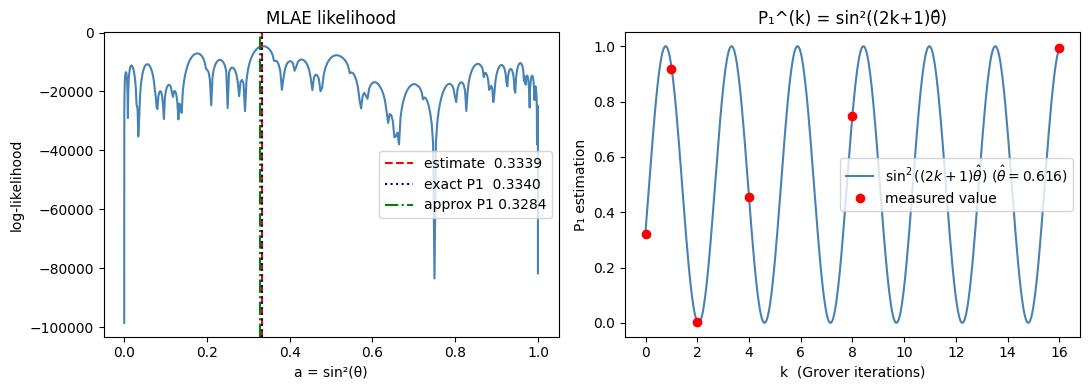

In [10]:
# ============================================================
# 5. Visualization
# ============================================================
theta_grid = np.linspace(1e-4, np.pi / 2 - 1e-4, 400)
ll_grid    = np.array([-neg_log_lik(t) for t in theta_grid])
a_grid     = np.sin(theta_grid)**2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(a_grid, ll_grid, color='steelblue')
axes[0].axvline(a_hat,     color='red',   ls='--',
                label=f'estimate  {a_hat:.4f}')
axes[0].axvline(P1_exact,  color='navy',  ls=':',
                label=f'exact P1  {P1_exact:.4f}')
axes[0].axvline(P1_approx, color='green', ls='-.',
                label=f'approx P1 {P1_approx:.4f}')
axes[0].set_xlabel('a = sin²(θ)')
axes[0].set_ylabel('log-likelihood')
axes[0].set_title('MLAE likelihood')
axes[0].legend()

k_smooth = np.linspace(0, max(k_list), 500)
P1_sine_curve = np.sin((2 * k_smooth + 1) * theta_hat)**2
axes[1].plot(k_smooth, P1_sine_curve, '-', color='steelblue',
             label=rf'$\sin^2((2k+1)\hat{{\theta}})$ ($\hat{{\theta}}={theta_hat:.3f}$)')
axes[1].plot(k_list, [h / N for h, N in zip(h_list, N_list)],
             'o', color='red', zorder=5, label='measured value')
axes[1].set_xlabel('k  (Grover iterations)')
axes[1].set_ylabel('P₁ estimation')
axes[1].set_title('P₁^(k) = sin²((2k+1)θ̂)')
axes[1].legend()

plt.tight_layout()
plt.show()

MLAE estimates the region where the log likelihood is maximized.

## Summary

This article showed how to implement the option-pricing algorithm {cite:p}`10.22331/q-2020-07-06-291` with Qamomile.
The key points are as follows.

* We encoded a log-normal distribution into a quantum state with Mottönen encoding and used uniformly controlled rotations to encode the payoff of a call option into the payoff-qubit amplitude. Use Qamomile's `amplitude_encoding` to load the state.
* We measured circuits with the Grover operator $\mathcal{Q}$ applied $k$ times for several values of $k$, then estimated the amplitude angle by maximum likelihood to calculate the expected payoff.